In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math
import pandas as pd
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap



In [2]:
df = pd.read_csv('PhaseScan_data.csv').sample(frac = 1)
print(df.columns)

# feature : whether the sample is phase separated or not
# Proteil_Dil : dilute phase G3BP1 concentraiton in uM
# Protein : total G3BP1 concentration in uM
# RNA: total RNA concentraiton in ng/ul
# Suramin: total suramin concentration in uM

Index(['feature', 'Protein_Dil', 'Protein', 'RNA', 'Suramin'], dtype='object')


In [3]:
# Function definition to extract phase boundary from data
# Based on phase separation probability

def phase_boundary(df, xcol, ycol, f_col,
                   bins=80, boundary_range=(0.4, 0.6),
                   smooth_sigma=1.0, cmap='coolwarm',
                   plot=True, contour=False,
                   slab_col=None, slab_val=None,     #surmain concentration slab
                   slab_thickness=None):
    

    # Filter slab if specified 
    if slab_col is not None and slab_val is not None and slab_thickness is not None:
        section = df[(df[slab_col] >= slab_val) &
                     (df[slab_col] < slab_val + slab_thickness)]
    else:
        section = df.copy()

    # Separate by phase classification 
    df_sep = section[section[f_col] == True]     # phase separated state
    df_dil = section[section[f_col] == False]    # homogeneous state

    # Compute histograms 
    H_sep, xedges, yedges = np.histogram2d(df_sep[xcol], df_sep[ycol], bins=bins)
    H_dil, _, _ = np.histogram2d(df_dil[xcol], df_dil[ycol], bins=[xedges, yedges])

    # Smooth histograms by Gaussian filter
    if smooth_sigma > 0:
        H_sep = gaussian_filter(H_sep, sigma=smooth_sigma, mode='reflect')
        H_dil = gaussian_filter(H_dil, sigma=smooth_sigma, mode='reflect')

    # Probability field
    H_total = H_sep + H_dil
    with np.errstate(invalid='ignore', divide='ignore'):
        P_sep = np.where(H_total > 0, H_sep / H_total, np.nan)

    # Grid coordinates (bin centers)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2
    Xc, Yc = np.meshgrid(xcenters, ycenters, indexing="ij")

    # Boundary extraction
    boundary_mask = (P_sep >= boundary_range[0]) & (P_sep <= boundary_range[1])
    boundary_points = np.vstack([Xc[boundary_mask], Yc[boundary_mask]]).T


    # Plot if called
    if plot:
        plt.figure(figsize=(6, 5))
        plt.pcolormesh(xedges, yedges, P_sep.T, cmap=cmap, shading='auto')
        plt.scatter(boundary_points[:, 0], boundary_points[:, 1],
                    color='k', s=8, label=f'Boundary {boundary_range}')
        plt.colorbar(label='$P_{sep}$')
        plt.xlabel(xcol)
        plt.ylabel(ycol)

        title = f"Phase Boundary on {xcol}–{ycol} plane"
        if slab_col is not None:
            title += f"\n{slab_col} = {slab_val}–{slab_val + slab_thickness}"
        plt.title(title)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    # Return results
    return {"boundary_points": boundary_points,
            "Xc": Xc, "Yc": Yc,
            "P_sep": P_sep,
            "xedges": xedges, "yedges": yedges,
            "section": section
           }


In [4]:
# Definition of functions for global fitting

# ---------------------
# Phase Boundary Model
# ---------------------
def model(x, s, c, p):
    return s * np.exp(c * x * np.exp(-p * x))


# ==============================================================
# Global Hill-coupled model (RNA-controlled)
# c = c0 * theta(R), p = p0 * theta(R)
# theta(R) = 1 / (1 + (R/KD)^n)
# ==============================================================
def model_global(X, KD, n, c0, p0, *slab_params):
    x = np.asarray(X[0], dtype=float)
    slab_idx = np.asarray(X[1], dtype=int)

    needed = np.max(slab_idx) + 1
    if len(slab_params) < needed:
        raise ValueError(
            f"Need {needed} slab params (s for each slab), got {len(slab_params)}. "
            f"len(popt) should be 4 + nslabs."
        )

    s_arr = np.array(slab_params, dtype=float)

    R = slab_values[slab_idx]
    KD = max(float(KD), 1e-15)
    n  = max(float(n), 1e-12)

    theta = 1.0 / (1.0 + (R / KD)**n)

    c = c0 * theta
    p = p0 * theta
    s = s_arr[slab_idx]

    return model(x, s, c, p)


# Function to plot phase boundary uncertainty envelope 
def get_fit_and_envelope(i, xx, popt, perr, model_global, lower=None, upper=None):
    X_plot = np.vstack([xx, np.full_like(xx, i, dtype=float)])
    y_fit = model_global(X_plot, *popt)

    y_iter = []
    base = np.array(popt, dtype=float)
    sig  = np.array(perr, dtype=float)

    # assumes parameter order:
    # [K_D, n, c_0, p_0, s0, s1, s2, ...]
    idx_s = 4 + i

    for dKD in (-0.1, +0.1):
        for dn in (-0.1, +0.1):
            for dc0 in (-0.1, +0.1):
                for dp0 in (-0.1, +0.1):
                    for ds in (-0.1, +0.1):
                        params = base.copy()

                        params[0] += dKD * sig[0]
                        params[1] += dn  * sig[1]
                        params[2] += dc0 * sig[2]
                        params[3] += dp0 * sig[3]
                        params[idx_s] += ds * sig[idx_s]

                        if lower is not None:
                            params = np.maximum(params, np.array(lower))
                        if upper is not None:
                            params = np.minimum(params, np.array(upper))

                        y_iter.append(model_global(X_plot, *params))

    y_hi = np.max(y_iter, axis=0)
    y_lo = np.min(y_iter, axis=0)

    return X_plot, y_fit, y_lo, y_hi

In [5]:
# -----------
# Slab setup
# -----------
slab_col = "RNA"
slab_values = np.array([20.0, 40.0, 60.0, 80.0, 100.0, 120.0], dtype=float)
slab_thickness = 10.0
nslabs = len(slab_values)
names = [f"{val:.0f} ng/µl" for val in slab_values]

# initiation for data number count
ndata_total = np.zeros(nslabs, dtype=int)     # total scatter points in section
ndata_dil   = np.zeros(nslabs, dtype=int)     # label==0
ndata_den   = np.zeros(nslabs, dtype=int)     # label==1
bcount_raw  = np.zeros(nslabs, dtype=int)     # boundary points extracted
bcount_fit  = np.zeros(nslabs, dtype=int)     # boundary points after maskextracted



# ----------------------------------
# Extract boundaries + COUNT DATA
# ----------------------------------
COORS = []
SECTIONS = []

for i, slab_val in enumerate(slab_values):
    result = phase_boundary( df=df, xcol='Suramin', ycol='Protein', f_col='feature',
        slab_col=slab_col, slab_val=float(slab_val), slab_thickness=slab_thickness,
        bins=60, boundary_range=(0.4, 0.6), smooth_sigma=1.0,
        plot=False, contour=False
          )

    section = result["section"]
    SECTIONS.append(section)
    
    # --- count total data in this slab ---
    label = section["feature"].values.astype(int)
    dil = section[label == 0]
    den = section[label == 1]

    ndata_dil[i] = len(dil)
    ndata_den[i] = len(den)
    ndata_total[i] = len(section)   


    # boundary extraction
    boundary = result["boundary_points"]
    x_data, y_data = boundary[:, 0], boundary[:, 1]
    mask = (x_data > 1e-6) & np.isfinite(x_data) & np.isfinite(y_data)
    x_m, y_m = x_data[mask], y_data[mask]
    COORS.append([x_m, y_m])
    bcount_raw[i] = len(x_m)

    # boundary points used for fitting 
    # drop outlier points
    mfit = (y_m < 4) & (x_m < 7)
    bcount_fit[i] = int(np.sum(mfit))


# --------------------------------------------------
# Build ONE concatenated dataset for global fitting
# --------------------------------------------------
x_all, y_all, idx_all = [], [], []
for i, (x_i, y_i) in enumerate(COORS):
    m = (y_i < 4) & (x_i < 7)
    x_i2 = x_i[m]
    y_i2 = y_i[m]
    if len(x_i2) == 0:
        continue
    x_all.append(x_i2)
    y_all.append(y_i2)
    idx_all.append(np.full_like(x_i2, i, dtype=int))

x_all = np.concatenate(x_all) if len(x_all) else np.array([], dtype=float)
y_all = np.concatenate(y_all) if len(y_all) else np.array([], dtype=float)
idx_all = np.concatenate(idx_all) if len(idx_all) else np.array([], dtype=int)

if len(x_all) == 0:
    raise RuntimeError("No boundary points survived the (y<4)&(x<7) mask across all slabs.")

X_all = np.vstack([x_all, idx_all.astype(float)])  


# --------------------------------------------------------------
# print data number counts
# --------------------------------------------------------------
print("\n=== Data Number Counts Per RNA Slab ===")
for i in range(nslabs):
    print(
        f"[RNA] = {names[i]}: "
        f"N = {ndata_total[i]} (dil={ndata_dil[i]}, den={ndata_den[i]}), "
        f"B = {bcount_fit[i]}/{bcount_raw[i]}"
    )
    



=== Data Number Counts Per RNA Slab ===
[RNA] = 20 ng/µl: N = 32647 (dil=14505, den=18142), B = 28/94
[RNA] = 40 ng/µl: N = 12695 (dil=6346, den=6349), B = 48/216
[RNA] = 60 ng/µl: N = 19382 (dil=8676, den=10706), B = 24/112
[RNA] = 80 ng/µl: N = 6810 (dil=3974, den=2836), B = 48/130
[RNA] = 100 ng/µl: N = 10997 (dil=6618, den=4379), B = 46/109
[RNA] = 120 ng/µl: N = 6120 (dil=4321, den=1799), B = 52/102


In [6]:
# --------------------------------------------------------------
# Global fit
# --------------------------------------------------------------

# initial guess and parameter bounds
KD0 = np.median(slab_values)
n0 = 3.0
c00 = 1.5
p00 = 0.2

# only one per-slab parameter now: s_i
s0_list = [0.3, 0.3, 0.7, 1.0, 1.3, 1.5]

p0 = [KD0, n0, c00, p00] + s0_list

lower = [1e-8, 1e-8, 1e-8, 1e-8] + [1e-8] * nslabs
upper = [np.inf, np.inf, np.inf, np.inf] + [np.inf] * nslabs

popt, pcov, infodict, errmsg, ier = curve_fit(
    model_global, X_all, y_all,
    p0=p0,
    bounds=(lower, upper),
    maxfev=20000,
    full_output=True
)

# Covariant error
perr = np.sqrt(np.diag(pcov))

print("Convergence flag (ier):", ier)
print("Message:", errmsg)
print("Number of function evaluations (nfev):", infodict["nfev"])


# --------------------------------------------------------------
# Store fitted per-slab parameters
# --------------------------------------------------------------
s_fit = np.array([popt[4+i] for i in range(nslabs)], dtype=float)
s_err = np.array([perr[4+i] for i in range(nslabs)], dtype=float)


# --------------------------------------------------------------
# Print fitted per-slab parameters
# --------------------------------------------------------------
print("\n=== Per-slab parameters ===")
for i in range(nslabs):
    print(
        f"[RNA] = {names[i]}: "
        f"s = {s_fit[i]:.6g} ± {s_err[i]:.3g}"
    )


# --------------------------------------------------------------
# Print fitted Hill parameters
# --------------------------------------------------------------
print("\n=== Hill parameters ===")
print(
    f"G3BP1-RNA K_D = {popt[0]:.4g} ± {perr[0]:.4g} ng/µl, "
    f"Hill coefficient n = {popt[1]:.4g} ± {perr[1]:.4g}"
)
print(
    f"c_0 = {popt[2]:.4g} ± {perr[2]:.4g}, "
    f"p_0 = {popt[3]:.4g} ± {perr[3]:.4g}"
)

Convergence flag (ier): 2
Message: `ftol` termination condition is satisfied.
Number of function evaluations (nfev): 44

=== Per-slab parameters ===
[RNA] = 20 ng/µl: s = 0.266054 ± 0.0718
[RNA] = 40 ng/µl: s = 0.704669 ± 0.0481
[RNA] = 60 ng/µl: s = 0.853426 ± 0.0333
[RNA] = 80 ng/µl: s = 1.29612 ± 0.0299
[RNA] = 100 ng/µl: s = 1.40653 ± 0.0295
[RNA] = 120 ng/µl: s = 1.58021 ± 0.0319

=== Hill parameters ===
G3BP1-RNA K_D = 24.93 ± 20.16 ng/µl, Hill coefficient n = 1.801 ± 0.3781
c_0 = 0.6293 ± 0.5916, p_0 = 0.1027 ± 0.1095


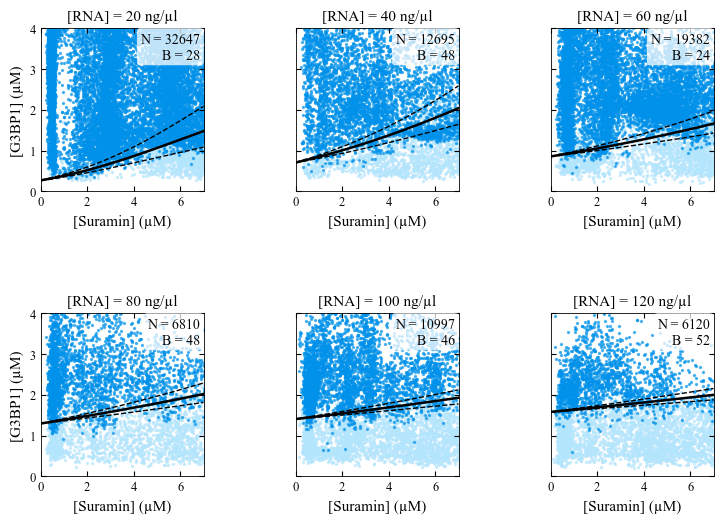

In [7]:
# --------------------------------------------------------------
# Plot
# --------------------------------------------------------------
n = nslabs
ncols = int(np.ceil(n / 2))
nrows = 2

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.0,
})

panel_size = 2.8
fig = plt.figure(figsize=(panel_size * ncols, panel_size * nrows))
axes = fig.subplots(nrows, ncols, sharey=True).flatten()

for ax in axes:
    ax.set_box_aspect(1)

xx = np.linspace(1e-8, 7, 5000)

for i, ax in enumerate(axes[:nslabs]):
    section = SECTIONS[i]
    label = section["feature"].values.astype(int)

    dil = section[label == 0]
    den = section[label == 1]

    ax.scatter(
        dil["Suramin"], dil["Protein"],
        s=2, color="#b3e5fc", alpha=0.6,
        rasterized=True
    )
    ax.scatter(
        den["Suramin"], den["Protein"],
        s=2, color="#0091ea", alpha=0.6,
        rasterized=True
    )

    X_plot, y_fit, yb_lo, yb_hi = get_fit_and_envelope(
        i, xx, popt, perr, model_global,
        lower=lower, upper=upper
    )

    ax.plot(xx, y_fit, color="black", lw=1.8)
    ax.plot(xx, yb_hi, color="black", ls="--", lw=1.0)
    ax.plot(xx, yb_lo, color="black", ls="--", lw=1.0)

    ax.set_xlabel("[Suramin] (µM)")
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 4)
    ax.set_title("[RNA] = " + names[i])

    txt = (
        f"N = {ndata_total[i]}\n"
        f"B = {bcount_fit[i]}"
    )

    ax.text(
        0.98, 0.98, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.75
        ),
        zorder=10
    )

# y-axis labels only on left column
for row in range(nrows):
    axes[row * ncols].set_ylabel("[G3BP1] (µM)")

# hide unused axes, if any
for ax in axes[nslabs:]:
    ax.axis("off")

plt.subplots_adjust(
    left=0.12,
    right=0.98,
    bottom=0.10,
    top=0.90,
    wspace=0.20,
    hspace=0.75
)

plt.show()

In [8]:
# Function to plot phase separation probability heat map
def phase_separation_probability(
    ax, df,
    xcol="RNA", ycol="Protein", f_col="feature",
    bins=80, smooth_sigma=1.0,
    slab_col=None, slab_val=None, slab_thickness=None,
    cmap="viridis", vmin=0.0, vmax=1.0
):

    # slab filtering
    if slab_col is not None and slab_val is not None and slab_thickness is not None:
        section = df[
            (df[slab_col] >= slab_val) &
            (df[slab_col] < slab_val + slab_thickness)
        ].copy()
    else:
        section = df.copy()

    # remove non-finite values
    section = section[
        np.isfinite(section[xcol]) &
        np.isfinite(section[ycol]) &
        np.isfinite(section[f_col])
    ].copy()

    if len(section) == 0:
        raise ValueError("No valid data points found after filtering.")

    # feature labels: dense / dilute
    label = section[f_col].values.astype(int)
    df_dil = section[label == 0]
    df_sep = section[label == 1]

    # shared bin edges from all points
    _, xedges, yedges = np.histogram2d(
        section[xcol], section[ycol],
        bins=bins
    )

    H_sep, _, _ = np.histogram2d(
        df_sep[xcol], df_sep[ycol],
        bins=[xedges, yedges]
    )

    H_dil, _, _ = np.histogram2d(
        df_dil[xcol], df_dil[ycol],
        bins=[xedges, yedges]
    )

    # smoothing
    if smooth_sigma is not None and smooth_sigma > 0:
        H_sep = gaussian_filter(H_sep, sigma=smooth_sigma, mode="reflect")
        H_dil = gaussian_filter(H_dil, sigma=smooth_sigma, mode="reflect")

    # probability field
    H_total = H_sep + H_dil

    with np.errstate(invalid="ignore", divide="ignore"):
        P_sep = np.where(H_total > 0, H_sep / H_total, np.nan)

    # mask empty bins
    P_plot = np.ma.array(P_sep, mask=np.isnan(P_sep))

    # plot on axis
    im = ax.pcolormesh(
        xedges, yedges, P_plot.T,
        shading="auto",
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        rasterized=True
    )

    return im, {
        "section": section,
        "H_sep": H_sep,
        "H_dil": H_dil,
        "H_total": H_total,
        "P_sep": P_sep,
        "xedges": xedges,
        "yedges": yedges
    }

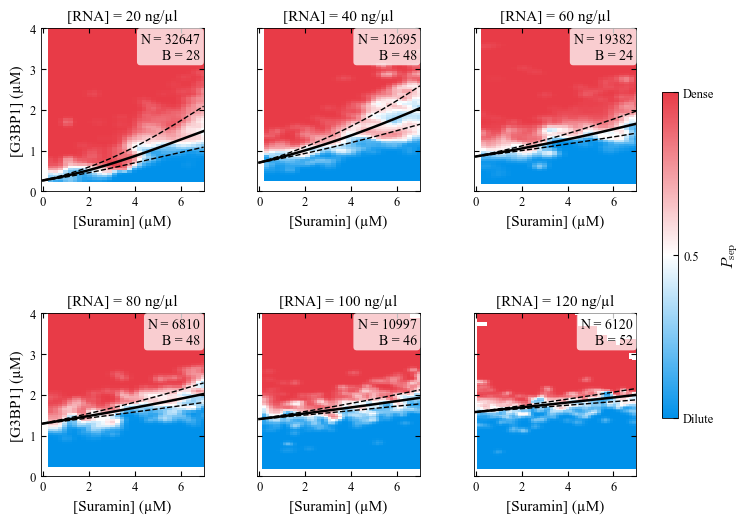

In [9]:
# --------------------------------------------------------------
# Phase-separation probability heat-map plot
# --------------------------------------------------------------

blue = "#0091ea"
red = "#e83b47"

blue_red_cmap = LinearSegmentedColormap.from_list(
    "blue_white_red_custom",
    [
        blue,       # low P_sep
        "#ffffff",  # neutral midpoint
        red         # high P_sep
    ]
)

n = nslabs
ncols = int(np.ceil(n / 2))
nrows = 2

panel_size = 2.8
fig = plt.figure(figsize=(panel_size * ncols, panel_size * nrows))
axes = fig.subplots(nrows, ncols, sharey=True).flatten()

for ax in axes:
    ax.set_box_aspect(1)

xx = np.linspace(1e-8, 7, 5000)

for i, ax in enumerate(axes[:nslabs]):

    im, res = phase_separation_probability(
        ax, SECTIONS[i],
        xcol="Suramin",
        ycol="Protein",
        f_col="feature",
        bins=150,
        smooth_sigma=1.0,
        cmap=blue_red_cmap,
        vmin=0.0,
        vmax=1.0
    )

    X_plot, y_fit, yb_lo, yb_hi = get_fit_and_envelope(
        i, xx, popt, perr, model_global,
        lower=lower, upper=upper
    )

    ax.plot(xx, y_fit, color="black", lw=1.8)
    ax.plot(xx, yb_hi, color="black", ls="--", lw=1.0)
    ax.plot(xx, yb_lo, color="black", ls="--", lw=1.0)

    ax.set_xlabel("[Suramin] (µM)")
    ax.set_xlim(-0.1, 7)
    ax.set_ylim(0, 4)
    ax.set_title("[RNA] = " + names[i])

    txt = (
        f"N = {ndata_total[i]}\n"
        f"B = {bcount_fit[i]}"
    )

    ax.text(
        0.98, 0.98, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.75
        ),
        zorder=10
    )

# y-axis labels only on left column
for row in range(nrows):
    axes[row * ncols].set_ylabel("[G3BP1] (µM)")

# hide unused axes if nslabs is not exactly nrows*ncols
for ax in axes[nslabs:]:
    ax.axis("off")

# shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes[:nslabs],
    fraction=0.025,
    pad=0.02
)
cbar.set_label(r"$P_{\mathrm{sep}}$")
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Dilute", "0.5", "Dense"])

plt.subplots_adjust(
    left=0.12,
    right=0.85,
    bottom=0.10,
    top=0.90,
    wspace=0.20,
    hspace=0.75
)

plt.show()

In [10]:
def theta_free_R(R, K_D, n):
    R = np.asarray(R, dtype=float)
    K_D = np.asarray(K_D, dtype=float)
    n = np.asarray(n, dtype=float)

    K_D = np.clip(K_D, 1e-15, np.inf)
    n = np.clip(n, 1e-12, np.inf)

    return 1.0 / (1.0 + (R / K_D)**n)

# Keep names chi3_model / dchi_model for compatibility
def chi3_model(R, A, K_D, n):
    return A * theta_free_R(R, K_D, n)


def dchi_model(R, A, K_D, n):
    return A * theta_free_R(R, K_D, n)


def global_model(R_all, A, K_D, n):
    R_all = np.asarray(R_all, dtype=float)

    if R_all.size % 2 != 0:
        raise ValueError("R_all must contain two concatenated datasets of equal length.")

    m = R_all.size // 2

    R1 = R_all[:m]
    R2 = R_all[m:]

    out1 = chi3_model(R1, A, K_D, n)
    out2 = dchi_model(R2, A, K_D, n)

    return np.concatenate([out1, out2])


# Normalize to reference point: [RNA] = 20 ng/µl by default
def normalize_with_error(y, sy, iref=0):
    """
    Normalize y -> y/y0 with error propagation.

    The reference point is treated as exactly y0/y0 = 1, avoiding the
    artificial sqrt(2) uncertainty from treating numerator and denominator
    as independent measurements.
    """
    y = np.asarray(y, dtype=float)
    sy = np.asarray(sy, dtype=float)

    if y.shape != sy.shape:
        raise ValueError("y and sy must have the same shape.")

    y0 = float(y[iref])
    sy0 = float(sy[iref])

    if not np.isfinite(y0) or y0 == 0.0:
        raise ValueError("Reference value y0 is zero or non-finite; cannot normalize.")

    if not np.isfinite(sy0):
        raise ValueError("Reference uncertainty sy0 is non-finite; cannot normalize.")

    yn = y / y0

    rel_y = np.zeros_like(y, dtype=float)
    mask = np.isfinite(y) & (y != 0.0) & np.isfinite(sy)
    rel_y[mask] = sy[mask] / y[mask]

    rel_y0 = sy0 / y0

    syn = np.abs(yn) * np.sqrt(rel_y**2 + rel_y0**2)

    # reference point is exactly normalized to itself
    yn[iref] = 1.0
    syn[iref] = abs(rel_y0)

    return yn, syn, y0, sy0


def safe_rel0(y0, sy0):
    y0 = float(y0)
    sy0 = float(sy0)

    if not np.isfinite(y0) or y0 == 0.0 or not np.isfinite(sy0):
        return 0.0

    return abs(sy0 / y0)

In [11]:
# --------------------------------------------------------------
# Compute c(R), p(R) and uncertainty propagation
# --------------------------------------------------------------
R = slab_values.astype(float)

KD_fit, n_fit, c0_fit, p0_fit = popt[:4]
perr = np.sqrt(np.diag(pcov))

# 4×4 covariance for [KD, n, c0, p0]
C4 = pcov[:4, :4]

KD_fit = max(float(KD_fit), 1e-15)
n_fit  = max(float(n_fit), 1e-12)

# Hill free fraction
u = (R / KD_fit)**n_fit
theta = 1.0 / (1.0 + u)

c_vals = c0_fit * theta
p_vals = p0_fit * theta


# --------------------------------------------------------------
# Derivatives for error propagation
# --------------------------------------------------------------

# theta = 1 / (1 + u), u = (R/KD)^n
dtheta_dKD = theta**2 * u * n_fit / KD_fit
dtheta_dn  = -theta**2 * u * np.log(R / KD_fit)

# c(R) derivatives wrt [KD, n, c0, p0]
dc_dKD = c0_fit * dtheta_dKD
dc_dn  = c0_fit * dtheta_dn
dc_dc0 = theta
dc_dp0 = np.zeros_like(theta)

# p(R) derivatives wrt [KD, n, c0, p0]
dp_dKD = p0_fit * dtheta_dKD
dp_dn  = p0_fit * dtheta_dn
dp_dc0 = np.zeros_like(theta)
dp_dp0 = theta

c_err = np.zeros_like(R, dtype=float)
p_err = np.zeros_like(R, dtype=float)

for i in range(len(R)):
    Jc = np.array([dc_dKD[i], dc_dn[i], dc_dc0[i], dc_dp0[i]])
    Jp = np.array([dp_dKD[i], dp_dn[i], dp_dc0[i], dp_dp0[i]])

    var_c = Jc @ C4 @ Jc
    var_p = Jp @ C4 @ Jp

    c_err[i] = np.sqrt(max(var_c, 0.0))
    p_err[i] = np.sqrt(max(var_p, 0.0))


# --------------------------------------------------------------
# Ratio r = p / c = p0 / c0 with covariance-aware uncertainty
# --------------------------------------------------------------
ratio_vals = p_vals / c_vals

# derivatives of r = p0 / c0 wrt [KD, n, c0, p0]
Jr = np.array([
    0.0,
    0.0,
    -p0_fit / c0_fit**2,
    1.0 / c0_fit
])

var_ratio = Jr @ C4 @ Jr
ratio_err_scalar = np.sqrt(max(var_ratio, 0.0))

ratio_err = np.full_like(R, ratio_err_scalar, dtype=float)


# --------------------------------------------------------------
# Print results
# --------------------------------------------------------------
print("\n=== c(R), p(R), and p/c with uncertainty ===")
for i in range(len(R)):
    print(
        f"RNA = {R[i]:.0f} ng/µl:  "
        f"c = {c_vals[i]:.6g} ± {c_err[i]:.3g},  "
        f"p = {p_vals[i]:.6g} ± {p_err[i]:.3g},  "
        f"p/c = {ratio_vals[i]:.6g} ± {ratio_err[i]:.3g}"
    )


=== c(R), p(R), and p/c with uncertainty ===
RNA = 20 ng/µl:  c = 0.376251 ± 0.134,  p = 0.0613912 ± 0.0316,  p/c = 0.163166 ± 0.032
RNA = 40 ng/µl:  c = 0.188238 ± 0.0222,  p = 0.0307139 ± 0.00895,  p/c = 0.163166 ± 0.032
RNA = 60 ng/µl:  c = 0.107336 ± 0.00878,  p = 0.0175136 ± 0.00415,  p/c = 0.163166 ± 0.032
RNA = 80 ng/µl:  c = 0.0686738 ± 0.0049,  p = 0.0112052 ± 0.00247,  p/c = 0.163166 ± 0.032
RNA = 100 ng/µl:  c = 0.0476704 ± 0.00428,  p = 0.00777817 ± 0.00176,  p/c = 0.163166 ± 0.032
RNA = 120 ng/µl:  c = 0.0350724 ± 0.0044,  p = 0.0057226 ± 0.00141,  p/c = 0.163166 ± 0.032


In [12]:
# --------------------------------------------------------------
# Physical quantities calculated from c(R), p(R), and p/c
# --------------------------------------------------------------

# L^1 = 10^3, L^3 = 100, L^12 = 10^4
competition_scale = 1.8e-8 * 1e4 * 10
repulsion_scale   = 1.8e-8 * 100 * 1e4 * 1e-2

competition_vals = p_vals / competition_scale
competition_err  = p_err  / competition_scale

repulsion_vals = c_vals / repulsion_scale
repulsion_err  = c_err  / repulsion_scale

kd_vals = ratio_vals * 1e3   # µM
kd_err  = ratio_err  * 1e3   # µM


# --------------------------------------------------------------
# Normalize physical quantities to [RNA] = 20 ng/µl
# --------------------------------------------------------------
iref = 0

competition_n, competition_nerr, comp_ref, comp_ref_err = normalize_with_error(
    competition_vals, competition_err, iref
)

repulsion_n, repulsion_nerr, rep_ref, rep_ref_err = normalize_with_error(
    repulsion_vals, repulsion_err, iref
)

kd_n, kd_nerr, kd_ref, kd_ref_err = normalize_with_error(
    kd_vals, kd_err, iref
)

rel0_chi3 = safe_rel0(rep_ref, rep_ref_err)
rel0_dchi = safe_rel0(comp_ref, comp_ref_err)
rel0_kd   = safe_rel0(kd_ref, kd_ref_err)


# --------------------------------------------------------------
# Print raw reference estimates
# --------------------------------------------------------------
print("\n--- Raw estimates at [RNA] = 20 ng/µl ---\n")
print(f"Δχ_ref = {comp_ref:.6g} ± {comp_ref_err:.3g}")
print(f"χ3_ref = {rep_ref:.6g} ± {rep_ref_err:.3g}")
print(f"K_D,ref = {kd_ref:.6g} ± {kd_ref_err:.3g} µM")
print(
    f"rel0: χ3 = {rel0_chi3:.3g}, "
    f"Δχ = {rel0_dchi:.3g}, "
    f"K_D = {rel0_kd:.3g}"
)


# --------------------------------------------------------------
# Print normalized physical quantities
# --------------------------------------------------------------
print("\n--- Normalized physical quantities to [RNA] = 20 ng/µl ---\n")
for i in range(len(R)):
    print(
        f"[RNA] = {R[i]:.0f} ng/µl: "
        f"χ3/χ3_ref = {repulsion_n[i]:.3g} ± {repulsion_nerr[i]:.3g},  "
        f"Δχ/Δχ_ref = {competition_n[i]:.3g} ± {competition_nerr[i]:.3g},  "
        f"K_D/K_D,ref = {kd_n[i]:.3g} ± {kd_nerr[i]:.3g}"
    )


--- Raw estimates at [RNA] = 20 ng/µl ---

Δχ_ref = 34.1062 ± 17.6
χ3_ref = 2090.28 ± 742
K_D,ref = 163.166 ± 32 µM
rel0: χ3 = 0.355, Δχ = 0.515, K_D = 0.196

--- Normalized physical quantities to [RNA] = 20 ng/µl ---

[RNA] = 20 ng/µl: χ3/χ3_ref = 1 ± 0.355,  Δχ/Δχ_ref = 1 ± 0.515,  K_D/K_D,ref = 1 ± 0.196
[RNA] = 40 ng/µl: χ3/χ3_ref = 0.5 ± 0.187,  Δχ/Δχ_ref = 0.5 ± 0.296,  K_D/K_D,ref = 1 ± 0.277
[RNA] = 60 ng/µl: χ3/χ3_ref = 0.285 ± 0.104,  Δχ/Δχ_ref = 0.285 ± 0.162,  K_D/K_D,ref = 1 ± 0.277
[RNA] = 80 ng/µl: χ3/χ3_ref = 0.183 ± 0.0661,  Δχ/Δχ_ref = 0.183 ± 0.102,  K_D/K_D,ref = 1 ± 0.277
[RNA] = 100 ng/µl: χ3/χ3_ref = 0.127 ± 0.0464,  Δχ/Δχ_ref = 0.127 ± 0.0713,  K_D/K_D,ref = 1 ± 0.277
[RNA] = 120 ng/µl: χ3/χ3_ref = 0.0932 ± 0.0351,  Δχ/Δχ_ref = 0.0932 ± 0.0532,  K_D/K_D,ref = 1 ± 0.277


In [13]:
# --------------------------------------------------------------
# Hill function plot and envelope
# --------------------------------------------------------------

x = np.asarray(slab_values, dtype=float)
x_ref = float(x[0])

x_fit_n = np.linspace(0.1, 140.0, 600)
x_fit_s_n = np.linspace(float(np.min(x)), 140.0, 600)

KD_fit, n_fit = float(popt[0]), float(popt[1])
KD_fit = max(KD_fit, 1e-15)
n_fit = max(n_fit, 1e-12)

# covariance sub-block for [K_D, n]
C_Kn = np.asarray(pcov[np.ix_([0, 1], [0, 1])], dtype=float)


# --------------------------------------------------------------
# Central normalized Hill prediction
# y_n(R) = theta(R) / theta(R_ref)
# --------------------------------------------------------------
theta_fit = theta_free_R(x_fit_n, KD_fit, n_fit)
theta_ref = float(theta_free_R(np.array([x_ref]), KD_fit, n_fit)[0])

yfit_n = theta_fit / theta_ref

yfit_chi3_n = yfit_n.copy()
yfit_dchi_n = yfit_n.copy()


# --------------------------------------------------------------
# Envelope for normalized Hill curve
# f(R) = theta(R, K_D, n) / theta(R_ref, K_D, n)
# --------------------------------------------------------------
def envelope_normalized(
    Rgrid, R_ref, K_D, n, C_Kn,
    rel0=0.0, nsigma=1.0, nsamp=6000, seed=1,
    tol=1e-10
):
    Rgrid = np.asarray(Rgrid, dtype=float)
    R_ref = float(R_ref)
    K_D = max(float(K_D), 1e-15)
    n = max(float(n), 1e-12)
    C_Kn = np.asarray(C_Kn, dtype=float)

    if C_Kn.shape != (2, 2) or not np.all(np.isfinite(C_Kn)):
        raise ValueError("C_Kn must be a finite 2x2 covariance matrix.")

    theta_ref0 = float(theta_free_R(np.array([R_ref]), K_D, n)[0])
    f0 = theta_free_R(Rgrid, K_D, n) / theta_ref0

    # If covariance is ill-conditioned or zero, return normalization-only band
    if not np.all(np.isfinite(C_Kn)) or np.any(np.diag(C_Kn) < 0):
        sig_param = np.zeros_like(f0)
    else:
        rng = np.random.default_rng(seed)

        samp = rng.multivariate_normal(
            mean=np.array([K_D, n], dtype=float),
            cov=C_Kn,
            size=int(nsamp)
        )

        Ks = np.clip(samp[:, 0], 1e-15, np.inf)
        ns = np.clip(samp[:, 1], 1e-12, np.inf)

        theta_num = theta_free_R(Rgrid[None, :], Ks[:, None], ns[:, None])
        theta_den = theta_free_R(np.array([[R_ref]]), Ks[:, None], ns[:, None])
        Ys = theta_num / theta_den

        alpha = 0.5 * (1.0 - math.erf(float(nsigma) / np.sqrt(2.0)))
        plo = 100.0 * alpha
        phi = 100.0 * (1.0 - alpha)

        ylo_p = np.percentile(Ys, plo, axis=0)
        yhi_p = np.percentile(Ys, phi, axis=0)

        sig_param = 0.5 * (yhi_p - ylo_p)

    sig_norm = abs(float(rel0)) * f0
    sig_tot = np.sqrt(sig_param**2 + sig_norm**2)

    ylo = f0 - float(nsigma) * sig_tot
    yhi = f0 + float(nsigma) * sig_tot

    # enforce exact normalized value at reference point if sampled
    idx = int(np.argmin(np.abs(Rgrid - R_ref)))
    if abs(Rgrid[idx] - R_ref) <= tol:
        ylo[idx] = 1.0 - float(nsigma) * abs(float(rel0))
        yhi[idx] = 1.0 + float(nsigma) * abs(float(rel0))

    return ylo, yhi


# --------------------------------------------------------------
# Envelopes including normalization uncertainty
# --------------------------------------------------------------
ylo_chi3_n, yhi_chi3_n = envelope_normalized(
    x_fit_s_n, x_ref, KD_fit, n_fit, C_Kn,
    rel0=rel0_chi3, nsigma=1.0, seed=1
)

ylo_dchi_n, yhi_dchi_n = envelope_normalized(
    x_fit_s_n, x_ref, KD_fit, n_fit, C_Kn,
    rel0=rel0_dchi, nsigma=1.0, seed=2
)


# --------------------------------------------------------------
# Normalized K_D prediction
# Because p/c = p0/c0, K_D is RNA-independent in this model.
# --------------------------------------------------------------
w = 1.0 / np.clip(kd_nerr, 1e-15, np.inf)**2

Kd_const = np.sum(w * kd_n) / np.sum(w)
Kd_const_err = np.sqrt(1.0 / np.sum(w))

yfit_kd_n = Kd_const * np.ones_like(x_fit_n)
ylo_kd_n = (Kd_const - Kd_const_err) * np.ones_like(x_fit_n)
yhi_kd_n = (Kd_const + Kd_const_err) * np.ones_like(x_fit_n)

In [14]:
# Hill function plot and envelope


# --------------------------------------------------------------
# x-axis: RNA slabs x_array
# --------------------------------------------------------------
x = np.asarray(slab_values, dtype=float)
x_ref = float(x[0])  # reference slab (RNA = 20)

# --------------------------------------------------------------
# Smooth grids
# --------------------------------------------------------------
x_fit_n = np.linspace(0.1, 140.0, 600)

# a shorter x_fit array
x_fit_s_n = np.linspace(float(np.min(x)), 140.0, 600)

# covariance sub-block for (K_D, n) from global boundary fit
C_Kn = pcov[np.ix_([0, 1], [0, 1])]

# --------------------------------------------------------------
# Central normalized Hill prediction:
#   y_n(R) = theta_free_R(R) / theta_free_R(R_ref)
# --------------------------------------------------------------
theta_fit = theta_free_R(x_fit_n, KD_fit, n_fit)
theta_ref = float(theta_free_R(np.array([x_ref]), KD_fit, n_fit)[0])
yfit_n = theta_fit / theta_ref   # Hill function curve also normalized

# Both three-body repulsion and competition described by this yfit_ratio
yfit_chi3_n = yfit_n
yfit_dchi_n = yfit_n

# --------------------------------------------------------------
# Normalized Kd prediction: constant = 1
# --------------------------------------------------------------
yfit_kd_n = np.ones_like(x_fit_n, dtype=float)

# Dashed envelope for normalized Kd:
# use the reference fractional uncertainty rel0_kd,
# so the band is 1 ± rel0_kd everywhere
ylo_kd_n = (1.0 - rel0_kd) * np.ones_like(x_fit_n, dtype=float)
yhi_kd_n = (1.0 + rel0_kd) * np.ones_like(x_fit_n, dtype=float)


# ==============================================================
#  Curve and total envelope for normalized Hill curve
#  f(R) = theta_free_R(R, K_D, n) / theta_free_R(R_ref, K_D, n)
# ==============================================================
def envelope_normalized( Rgrid, R_ref, K_D, n, C_Kn, rel0=0.0, nsigma=1.0, nsamp=6000, seed=1, tol=1e-12,):
    
    Rgrid = np.asarray(Rgrid, dtype=float)
    R_ref = float(R_ref)
    C_Kn = np.asarray(C_Kn, dtype=float)

    if C_Kn.shape != (2, 2) or not np.all(np.isfinite(C_Kn)):
        raise ValueError("C_Kn must be a finite 2x2 covariance matrix for (K_D, n).")

    use_norm_error = (rel0 is not None) and (float(rel0) != 0.0)

    # Central curve
    theta_ref0 = float(theta_free_R([R_ref], K_D, n)[0])
    f0 = theta_free_R(Rgrid, K_D, n) / theta_ref0

    # Convert nsigma to central Gaussian percentile interval
    alpha = 0.5 * (1.0 - np.math.erf(float(nsigma) / np.sqrt(2.0)))
    plo = 100.0 * alpha
    phi = 100.0 * (1.0 - alpha)
    
    # Monte Carlo sampling of (K_D, n)
    rng = np.random.default_rng(seed)
    samp = rng.multivariate_normal([float(K_D), float(n)], C_Kn, size=int(nsamp), )

    Ks = np.clip(samp[:, 0], 1e-15, np.inf)
    ns = np.clip(samp[:, 1], 1e-12, np.inf)

    # Evaluate sampled ratio curves
    theta_num = theta_free_R(Rgrid[None, :], Ks[:, None], ns[:, None])
    theta_den = theta_free_R(np.array([[R_ref]]), Ks[:, None], ns[:, None])
    Ys = theta_num / theta_den

    # parameter-only envelope from percentiles
    ylo_p = np.percentile(Ys, plo, axis=0)
    yhi_p = np.percentile(Ys, phi, axis=0)

    # Add optional normalization uncertainty in quadrature
    if use_norm_error:
        sig_param = 0.5 * (yhi_p - ylo_p)
        sig_norm = abs(float(rel0)) * f0
        sig_tot = np.sqrt(sig_param**2 + sig_norm**2)

        ylo = f0 - float(nsigma) * sig_tot
        yhi = f0 + float(nsigma) * sig_tot
    else:
        ylo = ylo_p
        yhi = yhi_p

    # Enforce exact behavior at reference if R_ref is on grid
    idx = int(np.argmin(np.abs(Rgrid - R_ref)))
    if abs(Rgrid[idx] - R_ref) <= tol:
        if use_norm_error:
            ylo[idx] = 1.0 - float(nsigma) * abs(float(rel0))
            yhi[idx] = 1.0 + float(nsigma) * abs(float(rel0))
        else:
            ylo[idx] = 1.0
            yhi[idx] = 1.0

    return ylo, yhi


# --------------------------------------------------------------
# Envelopes including normalization uncertainty
# --------------------------------------------------------------
ylo_chi3_n, yhi_chi3_n = envelope_normalized(
    x_fit_s_n, x_ref, KD_fit, n_fit, C_Kn, rel0=rel0_chi3, nsigma=1.0
)

ylo_dchi_n, yhi_dchi_n = envelope_normalized(
    x_fit_s_n, x_ref, KD_fit, n_fit, C_Kn, rel0=rel0_dchi, nsigma=1.0
)


# --------------------------------------------------------------
# Fitted normalized Kd_n to a constant (weighted mean) + 1σ band
# --------------------------------------------------------------
w = 1.0 / np.clip(kd_nerr, 1e-15, np.inf)**2
Kd_const = np.sum(w * kd_n) / np.sum(w)
Kd_const_err = np.sqrt(1.0 / np.sum(w))

yfit_kd_n = Kd_const * np.ones_like(x_fit_n)
ylo_kd_n = (Kd_const - Kd_const_err) * np.ones_like(x_fit_n)
yhi_kd_n = (Kd_const + Kd_const_err) * np.ones_like(x_fit_n)

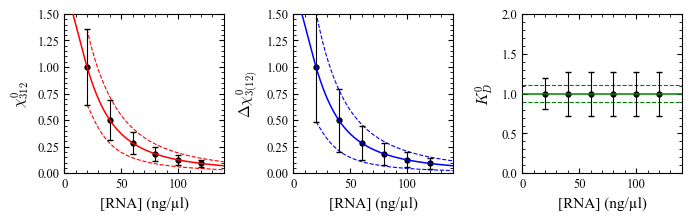

In [15]:
# -------------------------------
# Plot Fig. 4(b)
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.1), sharex=True)

colors = ["r", "b", "g"]

# normalized chi3 vs RNA
axes[0].errorbar(
    x, repulsion_n, yerr=repulsion_nerr,
    fmt="o", color="k", ms=3.5, lw=0.8,
    elinewidth=0.8, capsize=2.5, zorder=3
)
axes[0].plot(x_fit_n, yfit_chi3_n, "-", color=colors[0], lw=1.1, zorder=4)
axes[0].plot(x_fit_s_n, ylo_chi3_n, "--", color=colors[0], lw=0.8)
axes[0].plot(x_fit_s_n, yhi_chi3_n, "--", color=colors[0], lw=0.8)
axes[0].set_ylabel(r"$\chi^{0}_{312}$")
axes[0].set_ylim(0, 1.5)

# normalized dchi vs RNA
axes[1].errorbar(
    x, competition_n, yerr=competition_nerr,
    fmt="o", color="k", ms=3.5, lw=0.8,
    elinewidth=0.8, capsize=2.5, zorder=3
)
axes[1].plot(x_fit_n, yfit_dchi_n, "-", color=colors[1], lw=1.1, zorder=4)
axes[1].plot(x_fit_s_n, ylo_dchi_n, "--", color=colors[1], lw=0.8)
axes[1].plot(x_fit_s_n, yhi_dchi_n, "--", color=colors[1], lw=0.8)
axes[1].set_ylabel(r"$\Delta\chi^{0}_{3(12)}$")
axes[1].set_ylim(0, 1.5)

# normalized K_D vs RNA
axes[2].errorbar(
    x, kd_n, yerr=kd_nerr,
    fmt="o", color="k", ms=3.5, lw=0.8,
    elinewidth=0.8, capsize=2.5, zorder=3
)
axes[2].plot(x_fit_n, yfit_kd_n, "-", color=colors[2], lw=1.1, zorder=4)
axes[2].plot(x_fit_n, ylo_kd_n, "--", color=colors[2], lw=0.8)
axes[2].plot(x_fit_n, yhi_kd_n, "--", color=colors[2], lw=0.8)
axes[2].set_ylabel(r"$K^{0}_{D}$")
axes[2].set_ylim(0, 2.0)

for ax in axes:
    ax.set_xlabel("[RNA] (ng/µl)")
    ax.set_xlim(0, 140)
    ax.minorticks_on()
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.set_box_aspect(1)

plt.tight_layout(pad=0.3, w_pad=0.8)
plt.show()

In [16]:
# --------------------------------------
# Hill linearization for normalized Hill function:
# y_n(R) = theta(R) / theta(R_ref)
# --------------------------------------
def hill_normalized_linearized(
    R, y_n, yerr_n, R_ref, K, n,
    ymin_clip=-6.0,
    cap_dY=4.0
):
    """
    Exact Hill-linear transform for normalized data.

    y_n(R) = theta(R) / theta(R_ref)

    A = 1 / theta(R_ref) = 1 + (R_ref/K)^n

    Then:

        A / y_n - 1 = (R/K)^n

    so:

        Y = ln(A/y_n - 1) = n ln R - n ln K
    """

    R = np.asarray(R, dtype=float)
    y = np.asarray(y_n, dtype=float)
    sy = np.asarray(yerr_n, dtype=float)

    K = max(float(K), 1e-15)
    n = max(float(n), 1e-12)
    R_ref = max(float(R_ref), 1e-15)

    base = (
        np.isfinite(R) &
        np.isfinite(y) &
        np.isfinite(sy) &
        (R > 0) &
        (y > 0)
    )

    Rg = R[base]
    yg = y[base]
    sg = sy[base]

    X = np.log(Rg)

    A = 1.0 + (R_ref / K)**n

    g = A / yg - 1.0

    Y = np.full_like(g, ymin_clip, dtype=float)
    dY = np.full_like(g, 0.1, dtype=float)

    # Regular region: g > 0 and y < A
    mask_reg = np.isfinite(g) & (g > 0) & (yg < A)

    Y[mask_reg] = np.log(g[mask_reg])

    # dY/dy = -A / [y(A-y)]
    denom = yg[mask_reg] * (A - yg[mask_reg])
    dY[mask_reg] = np.abs(A / denom) * sg[mask_reg]

    if cap_dY is not None:
        dY = np.minimum(dY, float(cap_dY))

    return X, Y, dY, A


# ----------------------------------------------------------
# Envelope for Hill line:
# Y = n ln R - n ln K
# ----------------------------------------------------------
def hill_linearized_envelope(
    x, K_mean, n_mean, cov_Kn,
    nsamp=4000, pct=(16, 84), seed=1
):
    x = np.asarray(x, dtype=float)
    K_mean = max(float(K_mean), 1e-15)
    n_mean = max(float(n_mean), 1e-12)
    cov_Kn = np.asarray(cov_Kn, dtype=float)

    if cov_Kn.shape != (2, 2) or not np.all(np.isfinite(cov_Kn)):
        raise ValueError("cov_Kn must be a finite 2x2 covariance matrix.")

    rng = np.random.default_rng(seed)

    samp = rng.multivariate_normal(
        mean=np.array([K_mean, n_mean], dtype=float),
        cov=cov_Kn,
        size=int(nsamp)
    )

    Ks = np.clip(samp[:, 0], 1e-15, np.inf)
    ns = np.clip(samp[:, 1], 1e-12, np.inf)

    Ys = ns[:, None] * (x[None, :] - np.log(Ks)[:, None])

    y_med = np.percentile(Ys, 50, axis=0)
    y_lo = np.percentile(Ys, pct[0], axis=0)
    y_hi = np.percentile(Ys, pct[1], axis=0)

    return y_med, y_lo, y_hi


# ------------------------
# Hill-transform the data
# ------------------------
x = np.asarray(slab_values, dtype=float)
x_ref = float(x[0])

cov_Kn = np.asarray(pcov[np.ix_([0, 1], [0, 1])], dtype=float)

K_hill = float(KD_fit)
n_hill = float(n_fit)

X1, Y1, dY1, A1 = hill_normalized_linearized(
    x, repulsion_n, repulsion_nerr,
    R_ref=x_ref,
    K=K_hill,
    n=n_hill
)

X2, Y2, dY2, A2 = hill_normalized_linearized(
    x, competition_n, competition_nerr,
    R_ref=x_ref,
    K=K_hill,
    n=n_hill
)

print("A (χ3) =", A1)
print("A (Δχ) =", A2)

# Line grid
xmin_pos = np.min(x[x > 0])
R_line = np.linspace(0.9 * xmin_pos, 1.2 * np.max(x), 800)
X_line = np.log(R_line)

Y_med, Y_lo, Y_hi = hill_linearized_envelope(
    X_line, K_hill, n_hill, cov_Kn,
    nsamp=4000,
    pct=(16, 84),
    seed=1
)

A (χ3) = 1.672434648269137
A (Δχ) = 1.672434648269137


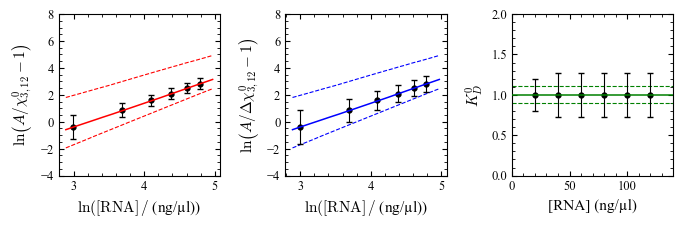

In [17]:
# ---------------
# Plot Fig. 2(c)
# ---------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.1))

# (a) Hill plot for normalized chi3
axes[0].errorbar(
    X1, Y1, yerr=dY1,
    fmt="o", color="k", ms=3.5,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes[0].plot(X_line, Y_med, "-", color="r", lw=1.1, zorder=4)
axes[0].plot(X_line, Y_lo, "--", color="r", lw=0.8)
axes[0].plot(X_line, Y_hi, "--", color="r", lw=0.8)
axes[0].set_xlabel(r"$\ln([\mathrm{RNA}]\,/$ (ng/µl))")
axes[0].set_ylabel(r"$\ln\!\left(A/\chi^{0}_{3,12}-1\right)$")
axes[0].set_ylim(-4, 8)

# (b) Hill plot for normalized dchi
axes[1].errorbar(
    X2, Y2, yerr=dY2,
    fmt="o", color="k", ms=3.5,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes[1].plot(X_line, Y_med, "-", color="b", lw=1.1, zorder=4)
axes[1].plot(X_line, Y_lo, "--", color="b", lw=0.8)
axes[1].plot(X_line, Y_hi, "--", color="b", lw=0.8)
axes[1].set_xlabel(r"$\ln([\mathrm{RNA}]\,/$ (ng/µl))")
axes[1].set_ylabel(r"$\ln\!\left(A/\Delta\chi^{0}_{3,12}-1\right)$")
axes[1].set_ylim(-4, 8)

# (c) normalized K_D^0 constant fit
axes[2].errorbar(
    x, kd_n, yerr=kd_nerr,
    fmt="o", color="k", ms=3.5,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes[2].plot(x_fit_n, yfit_kd_n, "-", color="g", lw=1.1, zorder=4)
axes[2].plot(x_fit_n, ylo_kd_n, "--", color="g", lw=0.8)
axes[2].plot(x_fit_n, yhi_kd_n, "--", color="g", lw=0.8)
axes[2].set_xlabel("[RNA] (ng/µl)")
axes[2].set_ylabel(r"$K_D^0$")
axes[2].set_xlim(0, 140)
axes[2].set_ylim(0, 2)

for ax in axes:
    ax.minorticks_on()
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.set_box_aspect(1)

plt.tight_layout(pad=0.3, w_pad=0.6)
plt.show()

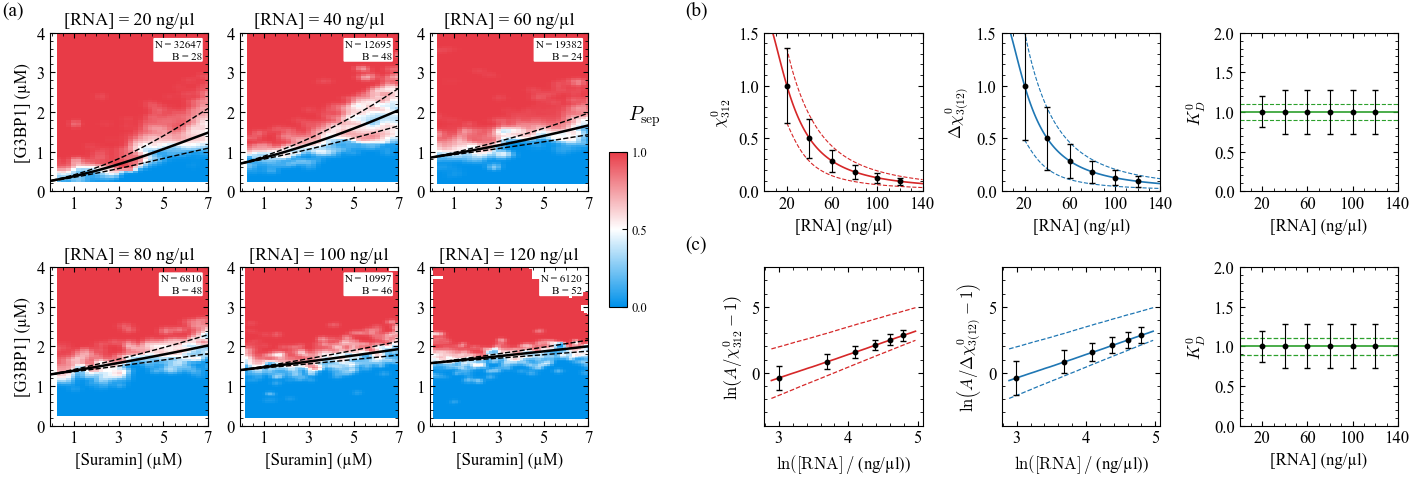

In [18]:
# ---------------
# Plot Fig. 4
# ---------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 0.8,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    "legend.frameon": False,
    "lines.linewidth": 1.2,
    "errorbar.capsize": 2.5,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

plt.rcParams["pdf.compression"] = 0
plt.rcParams["path.simplify"] = False
plt.rcParams["agg.path.chunksize"] = 0


def apply_ticks(ax):
    ax.minorticks_on()
    ax.tick_params(which="both", direction="in", top=True, right=True)


def subfig_label(ax, text, x=-0.28, y=1.12, fontsize=14, bold=False):
    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal"
    )


# fallback if using older colormap variable name
try:
    prob_cmap = blue_red_cmap
except NameError:
    prob_cmap = blue_cmap


# ----------------
# Layout Control
# ----------------
n = int(nslabs)
ncols_a = 3
nrows_a = int(np.ceil(n / ncols_a))

AX_A = 2.0
WSPACE_A = 0.20
HSPACE_A = 0.22

WSPACE_R = 0.50
HSPACE_R = 0.22

MLEFT, MRIGHT, MBOTTOM, MTOP = 0.85, 0.25, 0.70, 0.40
GUTTER = 1.50

gapA_w = WSPACE_A * AX_A
gapA_h = HSPACE_A * AX_A

W_left = ncols_a * AX_A + (ncols_a - 1) * gapA_w
H_left = nrows_a * AX_A + (nrows_a - 1) * gapA_h

gapR_h = HSPACE_R * AX_A
AX_R = (H_left - gapR_h) / 2.0

if AX_R <= 0:
    raise ValueError("H_left too small. Reduce HSPACE_R or increase AX_A.")

gapR_w = WSPACE_R * AX_R
W_right = 3 * AX_R + 2 * gapR_w

FIG_W = MLEFT + W_left + GUTTER + W_right + MRIGHT
FIG_H = MBOTTOM + H_left + MTOP

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[W_left, W_right],
    wspace=0.30
)

gs_r = gs[1].subgridspec(2, 1, hspace=HSPACE_R)


# ----------------------------------------------------------
# Fig. 4(a) LEFT: global fit phase boundary curves
# ----------------------------------------------------------
gs_a = gs[0].subgridspec(
    nrows_a, ncols_a,
    wspace=WSPACE_A,
    hspace=HSPACE_A
)

axes_a = np.array([
    fig.add_subplot(gs_a[r, c])
    for r in range(nrows_a)
    for c in range(ncols_a)
])

subfig_label(axes_a[0], "(a)", x=-0.30, y=1.20)

xx = np.linspace(1e-8, 7, 5000)

for i, ax in enumerate(axes_a[:nslabs]):
    section = SECTIONS[i]

    im, res = phase_separation_probability(
        ax, section,
        xcol="Suramin",
        ycol="Protein",
        f_col="feature",
        bins=150,
        smooth_sigma=1.0,
        cmap=prob_cmap,
        vmin=0.0,
        vmax=1.0
    )

    X_plot, y_fit, yb_lo, yb_hi = get_fit_and_envelope(
        i, xx, popt, perr, model_global,
        lower=lower,
        upper=upper
    )

    ax.plot(xx, y_fit, color="black", lw=1.8)
    ax.plot(xx, yb_hi, color="black", ls="--", lw=1.0)
    ax.plot(xx, yb_lo, color="black", ls="--", lw=1.0)

    ax.set_xlim(-0.1, 7)
    ax.set_ylim(0, 4)
    ax.set_xticks([1.0, 3.0, 5.0, 7.0])
    ax.set_title(f"[RNA] = {names[i]}")

    if i % ncols_a == 0:
        ax.set_ylabel("[G3BP1] (µM)")
    else:
        ax.set_ylabel("")

    if i >= ncols_a:
        ax.set_xlabel("[Suramin] (µM)")
    else:
        ax.set_xlabel("")

    txt = (
        f"N = {ndata_total[i]}\n"
        f"B = {bcount_fit[i]}"
    )

    ax.text(
        0.96, 0.96, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.1",
            facecolor="white",
            edgecolor="none",
            alpha=1.0
        ),
        zorder=10
    )

for ax in axes_a[nslabs:]:
    ax.axis("off")

for ax in axes_a[:nslabs]:
    apply_ticks(ax)
    ax.set_box_aspect(1)


# Colorbar for panel (a)
cbar_w, cbar_h = 0.010, 0.28
pos_top = axes_a[2].get_position()
pos_bot = axes_a[5].get_position()

cax = fig.add_axes([
    pos_top.x1 + 0.012,
    0.5 * (pos_top.y1 + pos_bot.y0) - 0.5 * cbar_h,
    cbar_w,
    cbar_h
])

cbar = fig.colorbar(im, cax=cax)
cbar.set_ticks([0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=9)
cbar.ax.text(
    2.0, 1.15,
    r"$P_{\mathrm{sep}}$",
    transform=cbar.ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14
)


# ----------------------------------------------------------
# Fig. 4(b) TOP-RIGHT: normalized physical quantities vs RNA
# ----------------------------------------------------------
gs_b = gs_r[0].subgridspec(1, 3, wspace=WSPACE_R)
axes_b = [fig.add_subplot(gs_b[0, j]) for j in range(3)]

subfig_label(axes_b[0], "(b)", x=-0.50, y=1.20)

# χ3 normalized
axes_b[0].errorbar(
    x, repulsion_n, yerr=repulsion_nerr,
    fmt="o", color="k", ms=3.2,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes_b[0].plot(x_fit_n, yfit_chi3_n, "-", color="tab:red", lw=1.2, zorder=2)
axes_b[0].plot(x_fit_s_n, ylo_chi3_n, "--", color="tab:red", lw=0.8)
axes_b[0].plot(x_fit_s_n, yhi_chi3_n, "--", color="tab:red", lw=0.8)
axes_b[0].set_ylabel(r"$\chi^{0}_{312}$")
axes_b[0].set_ylim(0, 1.5)

# Δχ normalized
axes_b[1].errorbar(
    x, competition_n, yerr=competition_nerr,
    fmt="o", color="k", ms=3.2,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes_b[1].plot(x_fit_n, yfit_dchi_n, "-", color="tab:blue", lw=1.2, zorder=2)
axes_b[1].plot(x_fit_s_n, ylo_dchi_n, "--", color="tab:blue", lw=0.8)
axes_b[1].plot(x_fit_s_n, yhi_dchi_n, "--", color="tab:blue", lw=0.8)
axes_b[1].set_ylabel(r"$\Delta\chi^{0}_{3(12)}$")
axes_b[1].set_ylim(0, 1.5)

# K_D normalized constant
axes_b[2].errorbar(
    x, kd_n, yerr=kd_nerr,
    fmt="o", color="k", ms=3.2,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes_b[2].plot(x_fit_n, yfit_kd_n, "-", color="tab:green", lw=1.2, zorder=2)
axes_b[2].plot(x_fit_n, ylo_kd_n, "--", color="tab:green", lw=0.8)
axes_b[2].plot(x_fit_n, yhi_kd_n, "--", color="tab:green", lw=0.8)
axes_b[2].set_ylabel(r"$K^{0}_{D}$")
axes_b[2].set_ylim(0, 2.0)

for ax in axes_b:
    ax.set_xlabel("[RNA] (ng/µl)")
    ax.set_xticks([20, 60, 100, 140])
    ax.set_xlim(0, 140)
    apply_ticks(ax)
    ax.set_box_aspect(1)


# ----------------------------------------------------------------
# Fig. 4(c) BOTTOM-RIGHT: Hill-linearized panels + KD constant fit
# ----------------------------------------------------------------
gs_c = gs_r[1].subgridspec(1, 3, wspace=WSPACE_R)
axes_c = [fig.add_subplot(gs_c[0, j]) for j in range(3)]

subfig_label(axes_c[0], "(c)", x=-0.50, y=1.20)

# χ3 linearized
axes_c[0].errorbar(
    X1, Y1, yerr=dY1,
    fmt="o", color="k", ms=3.2,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes_c[0].plot(X_line, Y_med, "-", color="tab:red", lw=1.2, zorder=2)
axes_c[0].plot(X_line, Y_lo, "--", color="tab:red", lw=0.9, zorder=2)
axes_c[0].plot(X_line, Y_hi, "--", color="tab:red", lw=0.9, zorder=2)
axes_c[0].set_xlabel(r"$\ln([\mathrm{RNA}]\,/$ (ng/µl))")
axes_c[0].set_ylabel(r"$\ln\!\left(A/\chi^{0}_{312}-1\right)$")
axes_c[0].set_ylim(-4, 8)

# Δχ linearized
axes_c[1].errorbar(
    X2, Y2, yerr=dY2,
    fmt="o", color="k", ms=3.2,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes_c[1].plot(X_line, Y_med, "-", color="tab:blue", lw=1.2, zorder=2)
axes_c[1].plot(X_line, Y_lo, "--", color="tab:blue", lw=0.9, zorder=2)
axes_c[1].plot(X_line, Y_hi, "--", color="tab:blue", lw=0.9, zorder=2)
axes_c[1].set_xlabel(r"$\ln([\mathrm{RNA}]\,/$ (ng/µl))")
axes_c[1].set_ylabel(r"$\ln\!\left(A/\Delta\chi^{0}_{3(12)}-1\right)$")
axes_c[1].set_ylim(-4, 8)

# K_D normalized constant
axes_c[2].errorbar(
    x, kd_n, yerr=kd_nerr,
    fmt="o", color="k", ms=3.2,
    lw=0.8, elinewidth=0.8, capsize=2.5,
    zorder=3
)
axes_c[2].plot(x_fit_n, yfit_kd_n, "-", color="tab:green", lw=1.2, zorder=2)
axes_c[2].plot(x_fit_n, ylo_kd_n, "--", color="tab:green", lw=0.9, zorder=2)
axes_c[2].plot(x_fit_n, yhi_kd_n, "--", color="tab:green", lw=0.9, zorder=2)
axes_c[2].set_xlabel("[RNA] (ng/µl)")
axes_c[2].set_ylabel(r"$K^{0}_{D}$")
axes_c[2].set_xticks([20, 60, 100, 140])
axes_c[2].set_xlim(0, 140)
axes_c[2].set_ylim(0, 2.0)

for ax in axes_c:
    apply_ticks(ax)
    ax.set_box_aspect(1)


# ==============================================================
# Export
# ==============================================================
#fig.savefig("Figure_5.pdf")
#fig.savefig("Figure_5.png", dpi=600)

plt.show()